# Notebook 01: Data Collection & Preprocessing

**CRISP-DM Phase: Data Understanding**

This notebook handles:
1. Loading raw documents from the corpus
2. Text cleaning and preprocessing
3. Corpus statistics and exploratory analysis
4. Saving processed documents

**Domain**: Irish Climate Action Policy

**Dataset**: Self-curated from publicly available sources including government policy documents, Wikipedia articles on Irish/EU climate policy, and environmental reports.

In [ ]:
# Standard imports
import sys
import json
from pathlib import Path

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, print_config
from src.data_loader import (
    load_all_documents,
    save_processed_documents,
    get_corpus_stats,
)

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

# Print configuration
print_config()

## 1.1 Load Raw Documents

Load all documents from the `data/raw/` directory. The corpus includes:
- Irish Climate Action Plan summary
- European Green Deal documentation
- Paris Agreement overview
- Climate change in Europe
- Emissions trading information
- Energy policy documents
- Transport and electricity sector information
- Carbon capture and storage information
- Climate change mitigation strategies

In [2]:
# Load all documents from the raw data directory
documents = load_all_documents(RAW_DATA_DIR)

print(f"\nLoaded {len(documents)} documents")
print("\nDocument details:")
for i, doc in enumerate(documents):
    title = doc['metadata'].get('title', doc['metadata']['source_file'])
    words = doc['metadata']['word_count']
    chars = doc['metadata']['cleaned_length']
    print(f"  {i+1}. {title}: {words:,} words ({chars:,} chars)")

2026-04-09 12:20:44,921 - rag_qa_system - INFO - Loaded PDF with PyPDF2: CCAC-AR2026-2-our-changing-climate-final.pdf (33 pages)


2026-04-09 12:20:44,931 - rag_qa_system - INFO -   Loaded: CCAC-AR2026-2-our-changing-climate-final.pdf (11504 words)


2026-04-09 12:20:53,018 - rag_qa_system - INFO - Loaded PDF with PyPDF2: Energy-in-Ireland-2025.pdf (238 pages)


2026-04-09 12:20:53,063 - rag_qa_system - INFO -   Loaded: Energy-in-Ireland-2025.pdf (60874 words)


2026-04-09 12:20:53,064 - rag_qa_system - INFO - Loaded text file: carbon_capture_and_storage.txt (43957 chars)


...

2026-04-09 12:20:58,412 - rag_qa_system - INFO -   Loaded: sustainable_energy_authority_of_ireland.txt (348 words)


2026-04-09 12:20:58,413 - rag_qa_system - INFO - Loaded text file: transport_in_ireland.txt (15348 chars)


2026-04-09 12:20:58,417 - rag_qa_system - INFO -   Loaded: transport_in_ireland.txt (2423 words)


2026-04-09 12:20:58,418 - rag_qa_system - INFO - Total documents loaded: 14



Loaded 14 documents

Document details:
  1. CCAC-AR2026-2-our-changing-climate-final.pdf: 11,504 words (83,742 chars)
  2. Energy-in-Ireland-2025.pdf: 60,874 words (400,375 chars)
  3. carbon_capture_and_storage.txt: 6,954 words (43,830 chars)
  4. climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf: 112,553 words (699,586 chars)
  5. climate_change_in_europe.txt: 7,746 words (48,250 chars)
  6. climate_change_mitigation.txt: 11,555 words (76,575 chars)
  7. electricity_sector_in_ireland.txt: 1,168 words (7,820 chars)
  8. emissions_trading.txt: 5,352 words (34,380 chars)
  9. energy_policy_of_the_european_union.txt: 4,735 words (30,088 chars)
  10. environmental_protection_agency_ireland.txt: 305 words (2,178 chars)
  11. european_green_deal.txt: 7,522 words (48,452 chars)
  12. paris_agreement.txt: 5,961 words (38,067 chars)
  13. sustainable_energy_authority_of_ireland.txt: 348 words (2,295 chars)
  14. transport_in_ireland.txt: 2,423 words (15,330 chars)


## 1.2 Corpus Statistics

In [3]:
# Compute and display corpus statistics
stats = get_corpus_stats(documents)

print("\n" + "=" * 60)
print("CORPUS STATISTICS")
print("=" * 60)
print(f"  Total documents:    {stats['num_documents']}")
print(f"  Total characters:   {stats['total_characters']:,}")
print(f"  Total words:        {stats['total_words']:,}")
print(f"  Avg words/doc:      {stats['avg_words_per_doc']:,.0f}")
print("=" * 60)


CORPUS STATISTICS
  Total documents:    14
  Total characters:   1,530,968
  Total words:        239,000
  Avg words/doc:      17,071


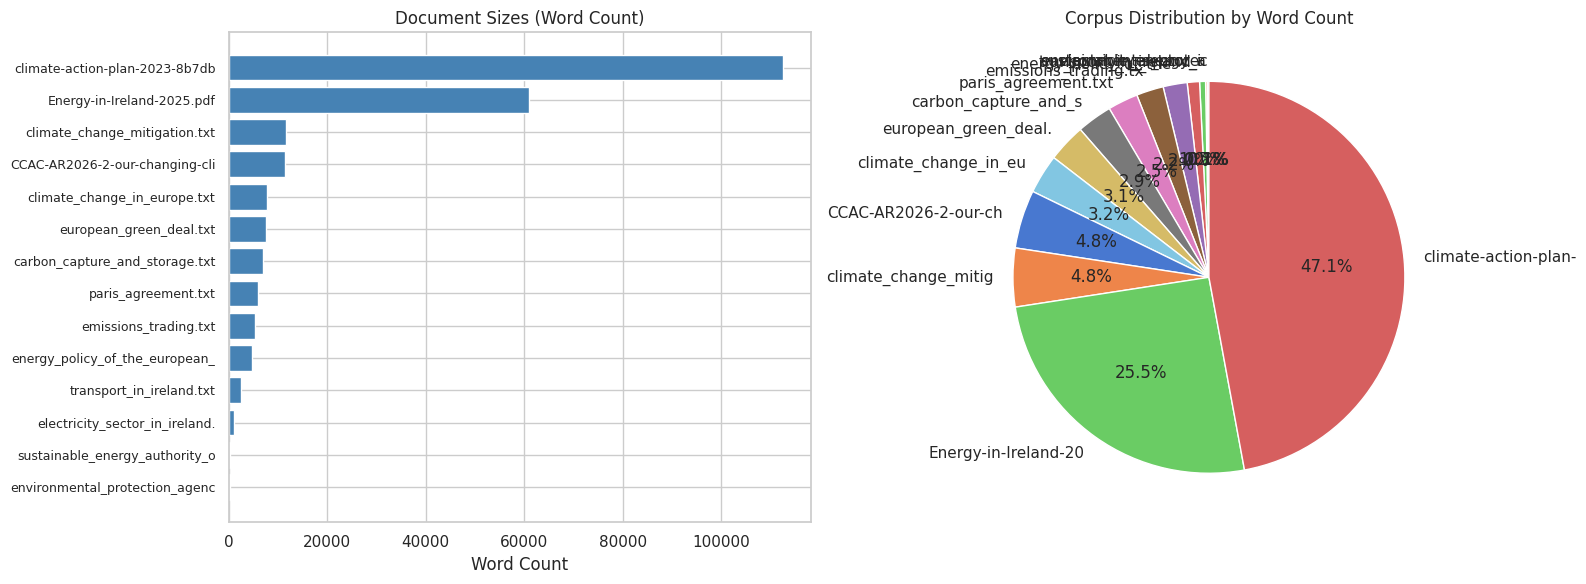

Figure saved to results/figures/corpus_statistics.png


In [4]:
# Visualize document sizes
doc_data = pd.DataFrame(stats['documents'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of word counts
ax1 = axes[0]
doc_data_sorted = doc_data.sort_values('words', ascending=True)
ax1.barh(doc_data_sorted['name'].str[:30], doc_data_sorted['words'], color='steelblue')
ax1.set_xlabel('Word Count')
ax1.set_title('Document Sizes (Word Count)')
ax1.tick_params(axis='y', labelsize=9)

# Pie chart of document distribution
ax2 = axes[1]
ax2.pie(doc_data_sorted['words'], labels=doc_data_sorted['name'].str[:20], 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Corpus Distribution by Word Count')

plt.tight_layout()
plt.savefig(str(project_root / 'results' / 'figures' / 'corpus_statistics.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/figures/corpus_statistics.png")

## 1.3 Save Processed Documents

In [5]:
# Save cleaned and processed documents
save_processed_documents(documents, PROCESSED_DATA_DIR)

# Verify saved files
print("\nProcessed files:")
for f in sorted(PROCESSED_DATA_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

2026-04-09 12:20:59,303 - rag_qa_system - INFO - Saved 14 processed documents to /home/umukesh/Desktop/dl/data/processed



Processed files:
  doc_00_CCAC-AR2026-2-our-changing-climate-final.txt (82.7 KB)
  doc_01_Energy-in-Ireland-2025.txt (392.6 KB)
  doc_02_carbon_capture_and_storage.txt (42.8 KB)
  doc_03_climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.txt (686.8 KB)
  doc_04_climate_change_in_europe.txt (47.2 KB)
  doc_05_climate_change_mitigation.txt (74.9 KB)
  doc_06_electricity_sector_in_ireland.txt (7.6 KB)
  doc_07_emissions_trading.txt (33.6 KB)
  doc_08_energy_policy_of_the_european_union.txt (29.4 KB)
  doc_09_environmental_protection_agency_ireland.txt (2.1 KB)
  doc_10_european_green_deal.txt (47.4 KB)
  doc_11_ireland_climate_action_plan.txt (9.5 KB)
  doc_11_paris_agreement.txt (37.3 KB)
  doc_12_paris_agreement.txt (37.3 KB)
  doc_12_sustainable_energy_authority_of_ireland.txt (2.2 KB)
  doc_13_sustainable_energy_authority_of_ireland.txt (2.2 KB)
  doc_13_transport_in_ireland.txt (15.0 KB)
  doc_14_transport_in_ireland.txt (15.0 KB)
  documents_metadata.json (3.2 KB)


## 1.4 Ground Truth Q&A Set

Load and inspect the manually created ground truth Q&A pairs used for evaluation.

In [6]:
# Load ground truth Q&A pairs
from src.config import GROUND_TRUTH_DIR

gt_path = GROUND_TRUTH_DIR / 'qa_pairs.json'
with open(gt_path, 'r') as f:
    qa_pairs = json.load(f)

print(f"Total Q&A pairs: {len(qa_pairs)}")
print(f"\nCategories:")

# Count by category
categories = {}
for pair in qa_pairs:
    cat = pair.get('category', 'unknown')
    categories[cat] = categories.get(cat, 0) + 1

for cat, count in sorted(categories.items(), key=lambda x: -x[1]):
    print(f"  {cat}: {count}")

print(f"\n--- Sample Q&A Pairs ---")
for i, pair in enumerate(qa_pairs[:3]):
    print(f"\nQ{i+1}: {pair['question']}")
    print(f"A{i+1}: {pair['answer'][:150]}...")
    print(f"Source: {pair['source']}")

Total Q&A pairs: 51

Categories:
  buildings: 7
  electricity: 5
  agriculture: 5
  transport: 4
  emissions: 4
  governance: 4
  eu_policy: 4
  energy: 3
  targets: 2
  carbon_tax: 2
  mechanisms: 2
  challenges: 2
  carbon_budgets: 1
  international: 1
  technology: 1
  methodology: 1
  industry: 1
  impacts: 1
  mitigation: 1

--- Sample Q&A Pairs ---

Q1: What is Ireland's 2030 greenhouse gas emissions reduction target?
A1: Ireland has a legally binding target to reduce greenhouse gas emissions by 51% by 2030 relative to 2018 levels, as established by the Climate Action a...
Source: ireland_climate_action_plan.txt

Q2: When must Ireland achieve climate neutrality?
A2: Ireland must achieve climate neutrality by 2050 at the latest, as mandated by the Climate Action and Low Carbon Development (Amendment) Act 2021....
Source: ireland_climate_action_plan.txt

Q3: What are Ireland's three carbon budgets and their allocations?
A3: Ireland's carbon budgets are: First Carbon Budget (2021-20

## 1.5 Summary

✅ Loaded and preprocessed all domain documents  
✅ Computed corpus statistics  
✅ Saved processed documents for downstream use  
✅ Verified ground truth Q&A dataset  

**Next**: Notebook 02 — Chunking Analysis